# CS 790 — Evaluation Framework
**Phase 1: Baseline classifier on real data**

This notebook trains a ResNet-18 classifier on real DIP joint X-rays to establish
baseline AUC numbers. Later phases add synthetic data and compare.

**What this notebook does:**
1. Loads the DIP manifest from Drive
2. Builds PyTorch datasets with proper augmentation
3. Trains ResNet-18 on two tasks: 5-class (KL 0-4) and binary (non-OA vs OA)
4. Handles class imbalance via weighted loss + balanced sampling
5. Evaluates on held-out test set: AUC, confusion matrix, ROC curves
6. Runs each experiment 3x with different seeds for stable averages
7. Saves everything to Drive for reproducibility

**Important design decisions:**
- Augmentation is train-only, on-the-fly (val/test untouched)
- Patient-level split prevents data leakage
- Each experiment runs 3x minimum → we report mean ± std
- When adding synthetic data later, max ratio is 2:1 (synthetic:real) to prevent the model from learning artifacts instead of real features

## 1. Setup

In [4]:
# ════════════════════════════════════════════════
# Mount Drive, extract images, install deps
# ════════════════════════════════════════════════

import os
import shutil
from google.colab import drive

# Ensure the mount point is empty before mounting
mount_point = '/content/drive'
if os.path.exists(mount_point) and os.path.isdir(mount_point):
    for item in os.listdir(mount_point):
        item_path = os.path.join(mount_point, item)
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.remove(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)

drive.mount(mount_point, force_remount=True)

!pip install -q pytorch-fid scikit-learn matplotlib seaborn

Mounted at /content/drive


In [5]:
# ════════════════════════════════════════════════
# Config — edit your path here
# ════════════════════════════════════════════════

import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc
from PIL import Image

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# ── EDIT THIS ──
PROJECT_DIR = "/content/drive/MyDrive/2-Education/0-BU_MSADA/Classes/3-Spring_2026/790_CV/CV-Project"

RAW_DIR = os.path.join(PROJECT_DIR, "data/raw")
SPLITS_DIR = os.path.join(PROJECT_DIR, "data/splits")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB


## 2. Extract images & load manifest

In [8]:
# ════════════════════════════════════════════════
# Extract zip to fast local disk (not Drive — too slow for training)
# This takes ~2-3 min. Skips if already extracted.
# ════════════════════════════════════════════════

import zipfile

IMAGES_DIR = "/content/finger_joints"
ZIP_PATH = os.path.join(RAW_DIR, "Finger_Joints.zip")

if os.path.exists(IMAGES_DIR) and len(os.listdir(IMAGES_DIR)) > 100:
    print(f"Already extracted — skipping")
else:
    print("Extracting zip to local disk...")
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(IMAGES_DIR)
    print(f"Done in {time.time()-t0:.0f}s")

# Find the actual image folder (might be nested: finger_joints/Finger Joints/)
img_root = IMAGES_DIR
for root, dirs, files in os.walk(IMAGES_DIR):
    pngs = [f for f in files if f.endswith('.png')]
    if len(pngs) > 1000:
        img_root = root
        break

print(f"Image root: {img_root}")
print(f"PNG files: {len([f for f in os.listdir(img_root) if f.endswith('.png')]):,}")

Extracting zip to local disk...
Done in 21s
Image root: /content/finger_joints/Finger Joints
PNG files: 41,060


In [9]:
# ════════════════════════════════════════════════
# Load the DIP-only manifest
# This was created by Jai's data prep pipeline.
# It maps each image filename to its KL grade and train/val/test split.
# ════════════════════════════════════════════════

manifest_path = os.path.join(SPLITS_DIR, "manifest_dip_only.csv")
df = pd.read_csv(manifest_path)

# Add 'filename' column by extracting from 'image_path'
# This is more robust as image_path should directly point to the file's relative path
df['filename'] = df['image_path'].apply(os.path.basename)

df = df.rename(columns={
    'v00_KL': 'KL', 'v00_JSN': 'JSN', 'v00_OP': 'OP', 'v00_ER': 'ER'
})

print(f"DIP manifest: {len(df):,} images, {df.patient_id.nunique()} patients")
print(f"Columns in manifest: {df.columns.tolist()}")

# ── Check split label convention (Jai uses 'val', we might expect 'validation') ──
split_labels = df['split'].unique().tolist()
print(f"Split labels in manifest: {split_labels}")

# Standardize: accept either 'val' or 'validation'
if 'val' in split_labels and 'validation' not in split_labels:
    df['split'] = df['split'].replace({'val': 'validation'})
    print("  → Renamed 'val' to 'validation'")

# Summary
for split in ['train', 'validation', 'test']:
    sub = df[df.split == split]
    print(f"  {split:12s}: {len(sub):5,} images, {sub.patient_id.nunique():4} patients")

print(f"\nKL distribution (DIP):")
total = len(df)
for kl in sorted(df.KL.unique()):
    n = len(df[df.KL == kl])
    bar = "█" * int(n / total * 50)
    print(f"  KL {kl}: {n:5,} ({n/total*100:5.1f}%) {bar}")

DIP manifest: 13,176 images, 3505 patients
Columns in manifest: ['patient_id', 'timepoint', 'joint_type', 'joint_num', 'joint_id', 'CY', 'ER', 'JSN', 'KL', 'ME', 'OP', 'PW', 'image_path', 'split', 'v06_KL', 'v06_JSN', 'v06_OP', 'v06_ER', 'filename']
Split labels in manifest: ['train', 'val', 'test']
  → Renamed 'val' to 'validation'
  train       : 9,202 images, 2453 patients
  validation  : 1,995 images,  526 patients
  test        : 1,979 images,  526 patients

KL distribution (DIP):
  KL 0.0: 8,476 ( 64.3%) ████████████████████████████████
  KL 1.0: 1,769 ( 13.4%) ██████
  KL 2.0: 2,541 ( 19.3%) █████████
  KL 3.0:   214 (  1.6%) 
  KL 4.0:   171 (  1.3%) 
  KL nan:     0 (  0.0%) 


## 3. Dataset & DataLoader

**Augmentation choices (train only):**
- Rotation ±15° — most effective single augmentation for OA X-rays (Prezja et al. Algorithms 2023)
- Horizontal flip — anatomically valid for finger joints
- Random zoom 0.9-1.1 — standard in OA literature
- Brightness/contrast jitter ±10% — generalizes across X-ray machines
- NO vertical flip — anatomically invalid (Hybrid Ensemble, Diagnostics 2026)

**Class imbalance handling:**
- Weighted cross-entropy — penalizes misclassifying rare KL 3/4 more
- WeightedRandomSampler — each batch sees roughly balanced classes
- These work at complementary stages (loss vs sampling)

In [10]:
# ════════════════════════════════════════════════
# Dataset class
# Loads an image from disk, applies transforms, returns (image, label)
# ════════════════════════════════════════════════

class OADataset(Dataset):
    """
    Simple dataset: reads image from disk, applies transform, returns label.
    For binary mode: KL 0-1 = 0 (non-OA), KL 2+ = 1 (OA)
    """
    def __init__(self, manifest_df, img_dir, transform=None, binary=False):
        self.df = manifest_df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.binary = binary

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        img = Image.open(img_path).convert('RGB')  # grayscale → 3ch for ImageNet pretrained

        if self.transform:
            img = self.transform(img)

        label = int(row['KL'])
        if self.binary:
            label = 0 if label <= 1 else 1  # non-OA (KL 0-1) vs OA (KL 2+)

        return img, label

print("✓ OADataset defined")

✓ OADataset defined


In [11]:
# ════════════════════════════════════════════════
# Transforms
#
# Train: augmentation + normalize
# Val/Test: just resize + normalize (NO augmentation — fair evaluation)
#
# Normalization uses Jai's computed stats: mean=0.2339, std=0.2349
# Replicated to 3 channels since we convert grayscale → RGB
# ════════════════════════════════════════════════

MEAN = [0.2339] * 3
STD = [0.2349] * 3
IMG_SIZE = 180

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),                         # ±15° rotation
    transforms.RandomHorizontalFlip(p=0.5),                # 50% chance flip
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),  # random zoom
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # slight brightness/contrast
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("✓ Transforms defined")

✓ Transforms defined


In [12]:
# ════════════════════════════════════════════════
# Build DataLoaders
#
# WeightedRandomSampler: oversamples minority classes so each batch
# is roughly balanced. Without this, 64% of every batch would be KL 0.
#
# Class weights for loss: inverse frequency. A misclassified KL 4
# contributes ~50x more to the loss than a misclassified KL 0.
# ════════════════════════════════════════════════

BATCH_SIZE = 32

def build_loaders(df, img_dir, binary=False, batch_size=BATCH_SIZE):
    """Build train/val/test DataLoaders with balanced sampling on train."""

    train_df = df[df.split == 'train'].copy()
    val_df = df[df.split == 'validation'].copy()
    test_df = df[df.split == 'test'].copy()

    # Drop rows with NaN KL values to prevent errors with .astype(int)
    train_df = train_df.dropna(subset=['KL'])
    val_df = val_df.dropna(subset=['KL'])
    test_df = test_df.dropna(subset=['KL'])

    # Create datasets
    train_ds = OADataset(train_df, img_dir, train_transform, binary=binary)
    val_ds = OADataset(val_df, img_dir, val_transform, binary=binary)
    test_ds = OADataset(test_df, img_dir, val_transform, binary=binary)

    # Compute labels for sampling/weighting
    if binary:
        train_labels = (train_df['KL'].values >= 2).astype(int)
        num_classes = 2
    else:
        train_labels = train_df['KL'].values.astype(int)
        num_classes = 5

    # Class weights (inverse frequency) for loss function
    class_counts = np.bincount(train_labels, minlength=num_classes).astype(float)
    class_weights = 1.0 / np.maximum(class_counts, 1)  # avoid div by zero
    class_weights = class_weights / class_weights.sum() * num_classes  # normalize
    class_weights_tensor = torch.FloatTensor(class_weights).to(device)

    # Weighted sampler for balanced batches
    sample_weights = [class_weights[label] for label in train_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    # DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print(f"  Train: {len(train_ds):,} images, {len(train_loader)} batches")
    print(f"  Val:   {len(val_ds):,} images")
    print(f"  Test:  {len(test_ds):,} images")
    print(f"  Class weights: {class_weights.round(2)}")

    return train_loader, val_loader, test_loader, class_weights_tensor, num_classes

print("✓ build_loaders defined")

✓ build_loaders defined


## 4. Model definition

In [13]:
# ════════════════════════════════════════════════
# ResNet-18 with replaced final layer
#
# Why ResNet-18?
# - Lightweight enough for 180x180 images on Colab
# - Pretrained ImageNet features transfer well to X-rays
# - Used in multiple OA classification papers
# ════════════════════════════════════════════════

def build_model(num_classes):
    """ResNet-18 pretrained on ImageNet, final FC replaced."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

print("✓ build_model defined")

✓ build_model defined


## 5. Training loop

**Key details:**
- Adam optimizer, lr=1e-4, cosine annealing scheduler
- Early stopping: save best model by validation AUC, patience=10 epochs
- Max 50 epochs (usually converges in 20-30)
- Logs loss + AUC per epoch for plotting later

In [14]:
# ════════════════════════════════════════════════
# Train one epoch
# ════════════════════════════════════════════════

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


# ════════════════════════════════════════════════
# Evaluate: compute loss, accuracy, and AUC
# ════════════════════════════════════════════════

@torch.no_grad()
def evaluate(model, loader, criterion, num_classes):
    model.eval()
    total_loss = 0
    all_labels = []
    all_probs = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)

        probs = torch.softmax(outputs, dim=1)
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()
    avg_loss = total_loss / len(all_labels)

    # AUC: one-vs-rest for multi-class, standard for binary
    if num_classes == 2:
        macro_auc = roc_auc_score(all_labels, all_probs[:, 1])
    else:
        # Some classes might not appear in small val sets — handle gracefully
        try:
            macro_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except ValueError:
            macro_auc = 0.0

    return avg_loss, macro_auc, all_labels, all_probs


print("✓ train_one_epoch and evaluate defined")

✓ train_one_epoch and evaluate defined


In [15]:
# ════════════════════════════════════════════════
# Full training run
#
# Returns the best model (by val AUC) and training history.
# We call this function 3 times with different seeds to get stable averages.
# ════════════════════════════════════════════════

def train_model(train_loader, val_loader, class_weights, num_classes,
                max_epochs=50, patience=10, lr=1e-4, seed=42):
    """
    Train ResNet-18 with early stopping on validation AUC.
    Returns: best model state dict, training history dict
    """
    # Set seed for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = build_model(num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_auc': []}
    best_auc = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(max_epochs):
        # Train
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        scheduler.step()

        # Validate
        val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, num_classes)

        # Log
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_auc'].append(val_auc)

        # Early stopping on val AUC
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        # Print every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d} | train_loss={train_loss:.4f} acc={train_acc:.3f} | "
                  f"val_loss={val_loss:.4f} val_auc={val_auc:.4f} | best={best_auc:.4f}")

        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    # Load best model
    model.load_state_dict(best_state)
    return model, history, best_auc


print("✓ train_model defined")

✓ train_model defined


## 6. Evaluation & visualization helpers

In [16]:
# ════════════════════════════════════════════════
# Plot training curves, confusion matrix, ROC curves
# ════════════════════════════════════════════════

def plot_training_curves(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(history['train_loss'], label='Train loss')
    ax1.plot(history['val_loss'], label='Val loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
    ax1.set_title('Loss')

    ax2.plot(history['val_auc'], label='Val AUC', color='green')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC'); ax2.legend()
    ax2.set_title('Validation AUC')

    plt.tight_layout()
    return fig


def plot_confusion_matrix(labels, preds, class_names, title=""):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    return fig


def plot_roc_curves(labels, probs, class_names, title=""):
    fig, ax = plt.subplots(figsize=(7, 6))
    n_classes = len(class_names)

    for i in range(n_classes):
        binary_labels = (labels == i).astype(int)
        if binary_labels.sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(binary_labels, probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{class_names[i]} (AUC={roc_auc:.3f})')

    ax.plot([0,1], [0,1], 'k--', alpha=0.3)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(title); ax.legend(loc='lower right')
    plt.tight_layout()
    return fig


def compute_per_class_auc(labels, probs, num_classes):
    """Compute one-vs-rest AUC for each class."""
    aucs = {}
    for i in range(num_classes):
        binary_labels = (labels == i).astype(int)
        if binary_labels.sum() == 0 or binary_labels.sum() == len(binary_labels):
            aucs[i] = float('nan')
        else:
            aucs[i] = roc_auc_score(binary_labels, probs[:, i])
    return aucs


print("✓ Plotting helpers defined")

✓ Plotting helpers defined


## 7. Run baseline experiments

**Why 3 runs?**
Neural network training is stochastic — different random seeds give different results.
Running 3x and averaging gives a stable estimate. We report mean ± std.

**Two experiments:**
1. 5-class (KL 0/1/2/3/4) — full severity grading
2. Binary (non-OA vs OA) — clinically meaningful threshold

In [ ]:
# ════════════════════════════════════════════════
# Run ALL experiments with auto-save (survives disconnects)
# ~45 min total
# ════════════════════════════════════════════════
N_RUNS = 3
SEEDS = [42, 123, 456]

import pickle

save_dir = os.path.join(MODELS_DIR, "eval_baseline")
os.makedirs(save_dir, exist_ok=True)

# ── 5-CLASS ──────────────────────────────────────
print("=" * 60)
print("EXPERIMENT 1: 5-CLASS KL GRADING")
print("=" * 60)

train_loader_5, val_loader_5, test_loader_5, cw_5, nc_5 = build_loaders(df, img_root, binary=False)

results_5class = []
for run_idx, seed in enumerate(SEEDS):
    print(f"\n--- Run {run_idx+1}/{N_RUNS} (seed={seed}) ---")
    model, history, best_val_auc = train_model(train_loader_5, val_loader_5, cw_5, nc_5, seed=seed)
    criterion = nn.CrossEntropyLoss(weight=cw_5)
    test_loss, test_auc, test_labels, test_probs = evaluate(model, test_loader_5, criterion, nc_5)
    per_class = compute_per_class_auc(test_labels, test_probs, nc_5)
    print(f"  TEST AUC: {test_auc:.4f}")
    results_5class.append({
        'seed': seed, 'test_auc': test_auc, 'per_class_auc': per_class,
        'history': history, 'test_labels': test_labels, 'test_probs': test_probs,
    })

pickle.dump(results_5class, open(os.path.join(save_dir, "results_5class.pkl"), "wb"))
aucs = [r['test_auc'] for r in results_5class]
print(f"\n5-CLASS: AUC = {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print("✓ Saved to Drive")

# ── BINARY ───────────────────────────────────────
print("\n" + "=" * 60)
print("EXPERIMENT 2: BINARY (non-OA vs OA)")
print("=" * 60)

train_loader_b, val_loader_b, test_loader_b, cw_b, nc_b = build_loaders(df, img_root, binary=True)

results_binary = []
for run_idx, seed in enumerate(SEEDS):
    print(f"\n--- Run {run_idx+1}/{N_RUNS} (seed={seed}) ---")
    model, history, best_val_auc = train_model(train_loader_b, val_loader_b, cw_b, nc_b, seed=seed)
    criterion = nn.CrossEntropyLoss(weight=cw_b)
    test_loss, test_auc, test_labels, test_probs = evaluate(model, test_loader_b, criterion, nc_b)
    print(f"  TEST AUC: {test_auc:.4f}")
    results_binary.append({
        'seed': seed, 'test_auc': test_auc,
        'history': history, 'test_labels': test_labels, 'test_probs': test_probs,
    })

pickle.dump(results_binary, open(os.path.join(save_dir, "results_binary.pkl"), "wb"))
aucs = [r['test_auc'] for r in results_binary]
print(f"\nBINARY: AUC = {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print("✓ Saved to Drive")

print("\n✓ Both experiments saved. Safe to visualize even if Colab disconnects.")

EXPERIMENT 1: 5-CLASS KL GRADING
  Train: 9,199 images, 288 batches
  Val:   1,993 images
  Test:  1,979 images
  Class weights: [0.05 0.24 0.17 2.05 2.5 ]

--- Run 1/3 (seed=42) ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


  Epoch   1 | train_loss=0.5147 acc=0.504 | val_loss=1.4497 val_auc=0.7570 | best=0.7570
  Epoch   5 | train_loss=0.1178 acc=0.731 | val_loss=1.0718 val_auc=0.8838 | best=0.8838
  Epoch  10 | train_loss=0.1038 acc=0.770 | val_loss=1.1530 val_auc=0.8800 | best=0.8838
  Epoch  15 | train_loss=0.0583 acc=0.816 | val_loss=1.4064 val_auc=0.8719 | best=0.8838
  Early stopping at epoch 15 (no improvement for 10 epochs)
  TEST AUC: 0.8584

--- Run 2/3 (seed=123) ---
  Epoch   1 | train_loss=0.5052 acc=0.517 | val_loss=1.2458 val_auc=0.7817 | best=0.7817
  Epoch   5 | train_loss=0.1205 acc=0.738 | val_loss=1.1591 val_auc=0.8676 | best=0.8704
  Epoch  10 | train_loss=0.1008 acc=0.782 | val_loss=1.3930 val_auc=0.8603 | best=0.8903
  Epoch  15 | train_loss=0.0618 acc=0.813 | val_loss=1.4011 val_auc=0.8673 | best=0.8963
  Epoch  20 | train_loss=0.0706 acc=0.825 | val_loss=1.4688 val_auc=0.8731 | best=0.8963
  Early stopping at epoch 24 (no improvement for 10 epochs)
  TEST AUC: 0.8809

--- Run 3/3 

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os, pickle

PROJECT_DIR = "/content/drive/MyDrive/2-Education/0-BU_MSADA/Classes/3-Spring_2026/790_CV/CV-Project"
save_dir = os.path.join(PROJECT_DIR, "models/eval_baseline")

print("Files in eval_baseline/:")
for f in sorted(os.listdir(save_dir)):
    size = os.path.getsize(os.path.join(save_dir, f)) / 1024
    print(f"  {f:40s} {size:.1f} KB")

# Check 5-class
if os.path.exists(os.path.join(save_dir, "results_5class.pkl")):
    r5 = pickle.load(open(os.path.join(save_dir, "results_5class.pkl"), "rb"))
    print(f"\n✓ 5-class: {len(r5)} runs saved")
    for r in r5:
        print(f"  seed={r['seed']}: AUC={r['test_auc']:.4f}")
else:
    print("\n✗ 5-class: NOT saved")

# Check binary
if os.path.exists(os.path.join(save_dir, "results_binary.pkl")):
    rb = pickle.load(open(os.path.join(save_dir, "results_binary.pkl"), "rb"))
    print(f"\n✓ Binary: {len(rb)} runs saved")
    for r in rb:
        print(f"  seed={r['seed']}: AUC={r['test_auc']:.4f}")
else:
    print("\n✗ Binary: NOT saved")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in eval_baseline/:
  README_eval_baseline.txt                 0.9 KB
  baseline_metrics.json                    0.9 KB
  results_5class.pkl                       166.0 KB
  results_binary.pkl                       0.0 KB

✓ 5-class: 3 runs saved
  seed=42: AUC=0.8584
  seed=123: AUC=0.8809
  seed=456: AUC=0.8944

✓ Binary: 1 runs saved
  seed=42: AUC=0.9617


In [17]:
# ════════════════════════════════════════════════
# BINARY — runs 2 and 3 only (run 1 already saved)
# Clear GPU memory first to prevent crashes
# ════════════════════════════════════════════════

import gc, pickle, torch
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB used")

N_RUNS = 3
SEEDS = [42, 123, 456]
save_dir = os.path.join(MODELS_DIR, "eval_baseline")

# Load existing results
results_binary = pickle.load(open(os.path.join(save_dir, "results_binary.pkl"), "rb"))
done_seeds = [r['seed'] for r in results_binary]
print(f"Already done: seeds {done_seeds}")

# Build loaders
train_loader_b, val_loader_b, test_loader_b, cw_b, nc_b = build_loaders(df, img_root, binary=True)

# Only run missing seeds
for seed in SEEDS:
    if seed in done_seeds:
        print(f"\n--- Seed {seed}: already done, skipping ---")
        continue

    print(f"\n--- Seed {seed} ---")

    # Clear memory before each run
    gc.collect()
    torch.cuda.empty_cache()

    model, history, best_val_auc = train_model(
        train_loader_b, val_loader_b, cw_b, nc_b, seed=seed)
    criterion = nn.CrossEntropyLoss(weight=cw_b)
    test_loss, test_auc, test_labels, test_probs = evaluate(
        model, test_loader_b, criterion, nc_b)

    print(f"  TEST AUC: {test_auc:.4f}")

    results_binary.append({
        'seed': seed, 'test_auc': test_auc,
        'history': history, 'test_labels': test_labels, 'test_probs': test_probs,
    })

    # Save after EACH run
    pickle.dump(results_binary, open(os.path.join(save_dir, "results_binary.pkl"), "wb"))
    print(f"  ✓ Saved to Drive")

    # Free the model immediately
    del model
    gc.collect()
    torch.cuda.empty_cache()

aucs = [r['test_auc'] for r in results_binary]
print(f"\nBINARY RESULTS: AUC = {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"Runs completed: {len(results_binary)}/3")

GPU memory: 0.00 GB used
Already done: seeds [42]
  Train: 9,199 images, 288 batches
  Val:   1,993 images
  Test:  1,979 images
  Class weights: [0.44 1.56]

--- Seed 42: already done, skipping ---

--- Seed 123 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


  Epoch   1 | train_loss=0.2937 acc=0.805 | val_loss=0.3222 val_auc=0.9467 | best=0.9467
  Epoch   5 | train_loss=0.1887 acc=0.876 | val_loss=0.3384 val_auc=0.9521 | best=0.9538
  Epoch  10 | train_loss=0.1451 acc=0.905 | val_loss=0.3781 val_auc=0.9474 | best=0.9538
  Early stopping at epoch 13 (no improvement for 10 epochs)
  TEST AUC: 0.9579
  ✓ Saved to Drive

--- Seed 456 ---
  Epoch   1 | train_loss=0.2879 acc=0.813 | val_loss=0.3109 val_auc=0.9475 | best=0.9475
  Epoch   5 | train_loss=0.1772 acc=0.880 | val_loss=0.3545 val_auc=0.9476 | best=0.9525
  Epoch  10 | train_loss=0.1425 acc=0.910 | val_loss=0.3670 val_auc=0.9492 | best=0.9557
  Epoch  15 | train_loss=0.1158 acc=0.926 | val_loss=0.3469 val_auc=0.9509 | best=0.9557
  Early stopping at epoch 19 (no improvement for 10 epochs)
  TEST AUC: 0.9613
  ✓ Saved to Drive

BINARY RESULTS: AUC = 0.9603 ± 0.0017
Runs completed: 3/3


In [24]:
import gc, pickle, torch
gc.collect()
torch.cuda.empty_cache()

save_dir = os.path.join(MODELS_DIR, "eval_baseline")
results_binary = pickle.load(open(os.path.join(save_dir, "results_binary.pkl"), "rb"))

# Drop the broken seed 42 (no predictions)
results_binary = [r for r in results_binary if 'test_labels' in r]
print(f"Kept {len(results_binary)} runs with predictions")

# Re-run seed 42
train_loader_b, val_loader_b, test_loader_b, cw_b, nc_b = build_loaders(df, img_root, binary=True)

print("\n--- Running seed 42 ---")
model, history, best_val_auc = train_model(train_loader_b, val_loader_b, cw_b, nc_b, seed=42)
criterion = nn.CrossEntropyLoss(weight=cw_b)
test_loss, test_auc, test_labels, test_probs = evaluate(model, test_loader_b, criterion, nc_b)
print(f"  TEST AUC: {test_auc:.4f}")

results_binary.append({
    'seed': 42, 'test_auc': test_auc,
    'history': history, 'test_labels': test_labels, 'test_probs': test_probs,
})

pickle.dump(results_binary, open(os.path.join(save_dir, "results_binary.pkl"), "wb"))
print("✓ Saved")

del model
gc.collect()
torch.cuda.empty_cache()

Kept 2 runs with predictions
  Train: 9,199 images, 288 batches
  Val:   1,993 images
  Test:  1,979 images
  Class weights: [0.44 1.56]

--- Running seed 42 ---
  Epoch   1 | train_loss=0.2945 acc=0.800 | val_loss=0.4167 val_auc=0.9458 | best=0.9458
  Epoch   5 | train_loss=0.1778 acc=0.880 | val_loss=0.3709 val_auc=0.9452 | best=0.9499
  Epoch  10 | train_loss=0.1460 acc=0.910 | val_loss=0.3283 val_auc=0.9516 | best=0.9533
  Epoch  15 | train_loss=0.1145 acc=0.931 | val_loss=0.3728 val_auc=0.9450 | best=0.9533
  Early stopping at epoch 17 (no improvement for 10 epochs)
  TEST AUC: 0.9602
✓ Saved


In [19]:
import pickle

save_dir = os.path.join(MODELS_DIR, "eval_baseline")

r5 = pickle.load(open(os.path.join(save_dir, "results_5class.pkl"), "rb"))
rb = pickle.load(open(os.path.join(save_dir, "results_binary.pkl"), "rb"))

print(f"5-class: {len(r5)} runs ✓")
for r in r5:
    print(f"  seed={r['seed']}: AUC={r['test_auc']:.4f}, has predictions: {'test_labels' in r}")

print(f"\nBinary: {len(rb)} runs ✓")
for r in rb:
    print(f"  seed={r['seed']}: AUC={r['test_auc']:.4f}, has predictions: {'test_labels' in r}")

5-class: 3 runs ✓
  seed=42: AUC=0.8584, has predictions: True
  seed=123: AUC=0.8809, has predictions: True
  seed=456: AUC=0.8944, has predictions: True

Binary: 3 runs ✓
  seed=42: AUC=0.9617, has predictions: False
  seed=123: AUC=0.9579, has predictions: True
  seed=456: AUC=0.9613, has predictions: True


## 8. Visualize results (using best run)

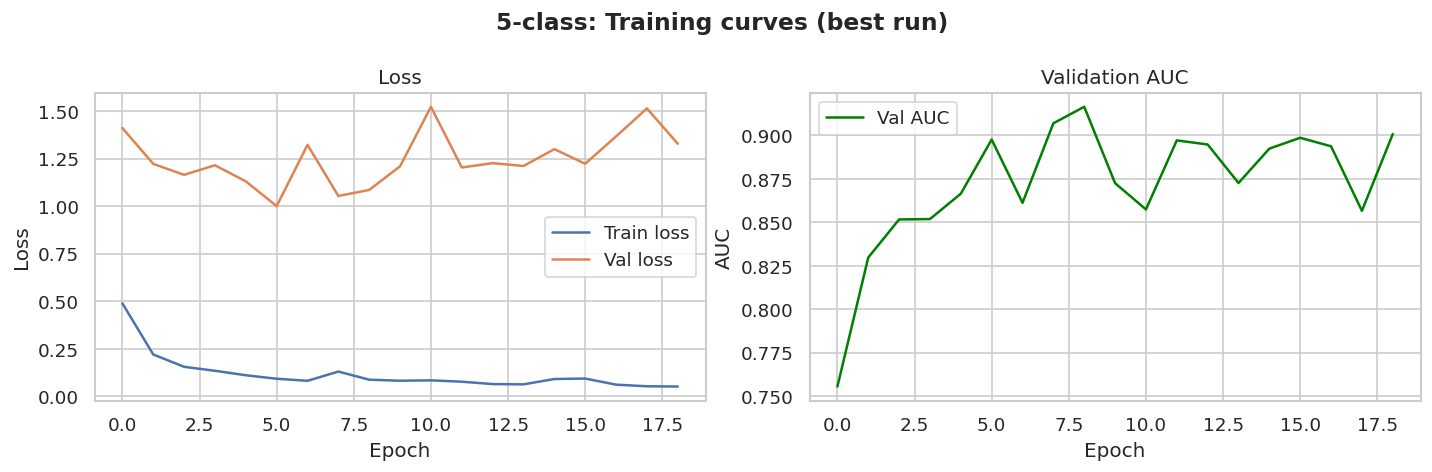

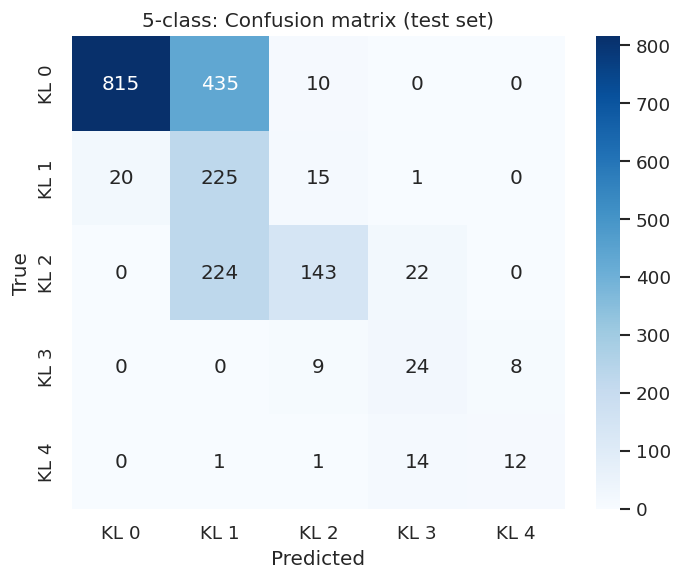

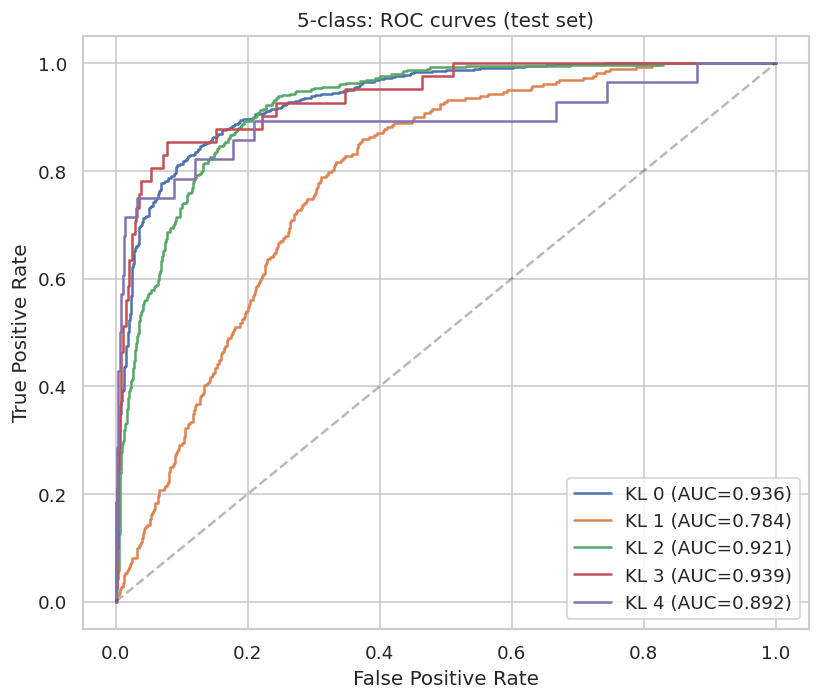

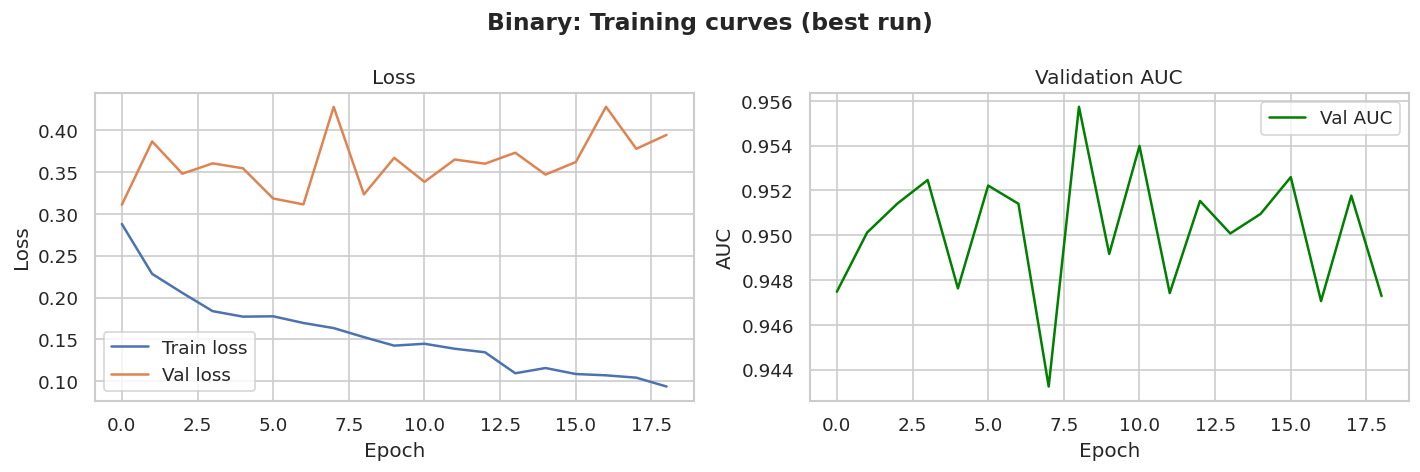

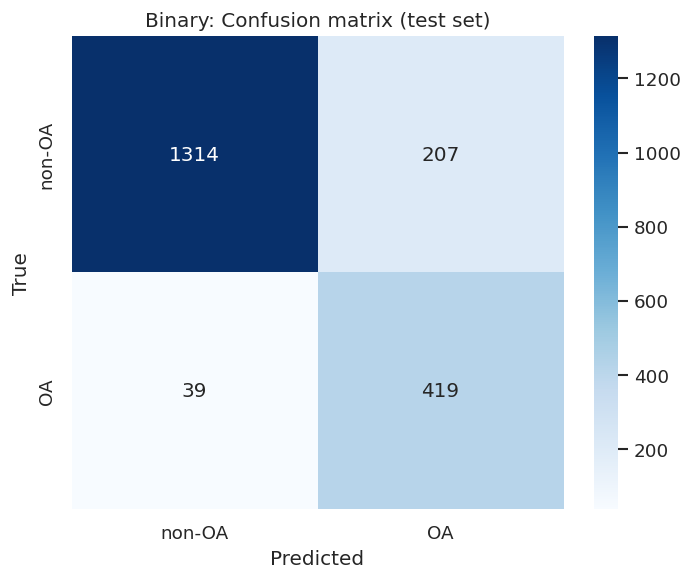

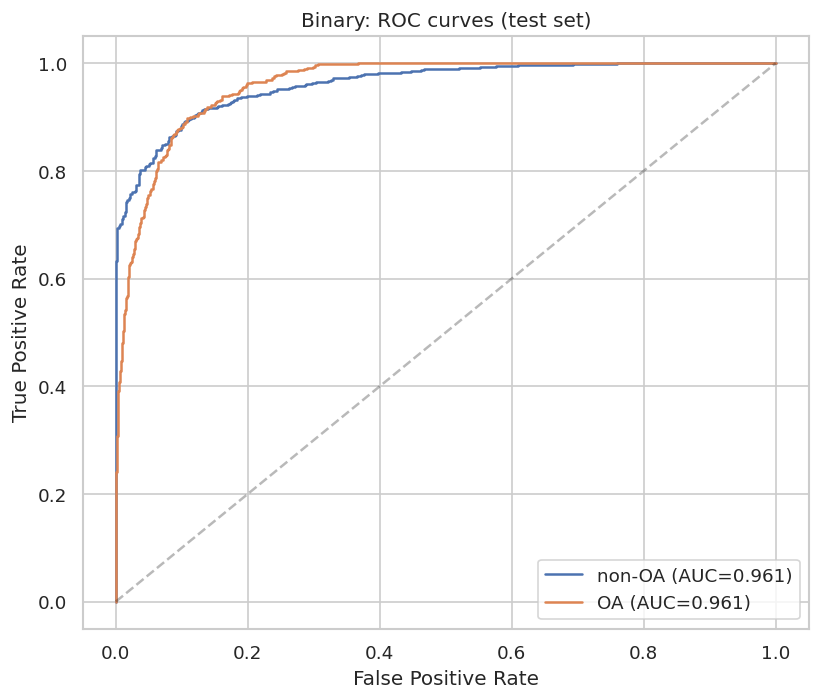

In [25]:
# ════════════════════════════════════════════════
# Pick best run by test AUC, plot everything
# ════════════════════════════════════════════════
# Load from Drive if not in memory
import pickle
try:
    _ = results_5class[0]['test_labels']
except (NameError, KeyError):
    save_dir = os.path.join(MODELS_DIR, "eval_baseline")
    results_5class = pickle.load(open(os.path.join(save_dir, "results_5class.pkl"), "rb"))
    results_binary = pickle.load(open(os.path.join(save_dir, "results_binary.pkl"), "rb"))
    print("✓ Loaded from Drive")
# 5-class: best run
best_5 = max(results_5class, key=lambda r: r['test_auc'])
kl_names = ['KL 0', 'KL 1', 'KL 2', 'KL 3', 'KL 4']

fig1 = plot_training_curves(best_5['history'], '5-class: Training curves (best run)')
plt.show()

fig2 = plot_confusion_matrix(
    best_5['test_labels'], best_5['test_probs'].argmax(axis=1),
    kl_names, '5-class: Confusion matrix (test set)')
plt.show()

fig3 = plot_roc_curves(best_5['test_labels'], best_5['test_probs'],
    kl_names, '5-class: ROC curves (test set)')
plt.show()

# Binary: best run
best_b = max(results_binary, key=lambda r: r['test_auc'])
bin_names = ['non-OA', 'OA']

fig4 = plot_training_curves(best_b['history'], 'Binary: Training curves (best run)')
plt.show()

fig5 = plot_confusion_matrix(
    best_b['test_labels'], best_b['test_probs'].argmax(axis=1),
    bin_names, 'Binary: Confusion matrix (test set)')
plt.show()

fig6 = plot_roc_curves(best_b['test_labels'], best_b['test_probs'],
    bin_names, 'Binary: ROC curves (test set)')
plt.show()

## 9. Save results to Drive

In [26]:
# ════════════════════════════════════════════════
# Save everything to Drive
# ════════════════════════════════════════════════

save_dir = os.path.join(MODELS_DIR, "eval_baseline")
os.makedirs(save_dir, exist_ok=True)

# Metrics JSON
metrics = {
    '5class': {
        'mean_auc': float(np.mean([r['test_auc'] for r in results_5class])),
        'std_auc': float(np.std([r['test_auc'] for r in results_5class])),
        'runs': [{'seed': r['seed'], 'test_auc': float(r['test_auc']),
                  'per_class_auc': {str(k): round(float(v), 4) for k, v in r['per_class_auc'].items()}}
                 for r in results_5class],
    },
    'binary': {
        'mean_auc': float(np.mean([r['test_auc'] for r in results_binary])),
        'std_auc': float(np.std([r['test_auc'] for r in results_binary])),
        'runs': [{'seed': r['seed'], 'test_auc': float(r['test_auc'])}
                 for r in results_binary],
    }
}

with open(os.path.join(save_dir, 'baseline_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

# Save figures
fig1.savefig(os.path.join(save_dir, '5class_training_curves.png'), dpi=150, bbox_inches='tight')
fig2.savefig(os.path.join(save_dir, '5class_confusion_matrix.png'), dpi=150, bbox_inches='tight')
fig3.savefig(os.path.join(save_dir, '5class_roc_curves.png'), dpi=150, bbox_inches='tight')
fig4.savefig(os.path.join(save_dir, 'binary_training_curves.png'), dpi=150, bbox_inches='tight')
fig5.savefig(os.path.join(save_dir, 'binary_confusion_matrix.png'), dpi=150, bbox_inches='tight')
fig6.savefig(os.path.join(save_dir, 'binary_roc_curves.png'), dpi=150, bbox_inches='tight')

print(f"✓ Saved to: {save_dir}")
for f in sorted(os.listdir(save_dir)):
    print(f"  {f}")

✓ Saved to: /content/drive/MyDrive/2-Education/0-BU_MSADA/Classes/3-Spring_2026/790_CV/CV-Project/models/eval_baseline
  5class_confusion_matrix.png
  5class_roc_curves.png
  5class_training_curves.png
  README_eval_baseline.txt
  baseline_metrics.json
  binary_confusion_matrix.png
  binary_roc_curves.png
  binary_training_curves.png
  results_5class.pkl
  results_binary.pkl


## 10. Final summary

In [27]:
# ════════════════════════════════════════════════
# Print the numbers you'll compare against later
# ════════════════════════════════════════════════

print("=" * 60)
print("  BASELINE RESULTS (real data only, DIP joints)")
print("=" * 60)

print(f"\n5-CLASS (KL 0-4):")
print(f"  Macro AUC: {metrics['5class']['mean_auc']:.4f} ± {metrics['5class']['std_auc']:.4f}")
for run in metrics['5class']['runs']:
    pca = run.get('per_class_auc', {})
    pca_str = ", ".join([f"KL{k}={v:.3f}" for k, v in pca.items()])
    print(f"  Run (seed={run['seed']}): AUC={run['test_auc']:.4f} | {pca_str}")

print(f"\nBINARY (non-OA vs OA):")
print(f"  AUC: {metrics['binary']['mean_auc']:.4f} ± {metrics['binary']['std_auc']:.4f}")
for run in metrics['binary']['runs']:
    print(f"  Run (seed={run['seed']}): AUC={run['test_auc']:.4f}")

print(f"\n" + "=" * 60)
print("  NEXT: When synthetic images arrive, re-run with augmented data")
print("  Compare: AUC(real only) vs AUC(real + synthetic)")
print("  Max ratio: 2:1 synthetic:real to avoid learning artifacts")
print("=" * 60)

  BASELINE RESULTS (real data only, DIP joints)

5-CLASS (KL 0-4):
  Macro AUC: 0.8779 ± 0.0148
  Run (seed=42): AUC=0.8584 | KL0=0.925, KL1=0.739, KL2=0.918, KL3=0.954, KL4=0.756
  Run (seed=123): AUC=0.8809 | KL0=0.938, KL1=0.750, KL2=0.907, KL3=0.888, KL4=0.920
  Run (seed=456): AUC=0.8944 | KL0=0.936, KL1=0.784, KL2=0.921, KL3=0.939, KL4=0.892

BINARY (non-OA vs OA):
  AUC: 0.9598 ± 0.0014
  Run (seed=123): AUC=0.9579
  Run (seed=456): AUC=0.9613
  Run (seed=42): AUC=0.9602

  NEXT: When synthetic images arrive, re-run with augmented data
  Compare: AUC(real only) vs AUC(real + synthetic)
  Max ratio: 2:1 synthetic:real to avoid learning artifacts


## 11. Template for Phase 2+ (adding synthetic data)

When CycleGAN or diffusion outputs are ready, use this template.
The key constraint: **synthetic:real ratio must not exceed 2:1**.
This prevents the model from learning GAN/diffusion artifacts instead of real OA features.

In [ ]:
# ════════════════════════════════════════════════
# TEMPLATE: Adding synthetic data (Phase 2/3)
# Uncomment and fill in when synthetic images are ready
# ════════════════════════════════════════════════

# # 1. Load synthetic manifest (same format as real manifest)
# synthetic_df = pd.read_csv("path/to/synthetic_manifest.csv")
# print(f"Synthetic images: {len(synthetic_df):,}")
#
# # 2. Enforce 2:1 max ratio (synthetic:real)
# real_train = df[df.split == 'train']
# max_synthetic = len(real_train) * 2  # 2:1 ratio cap
# if len(synthetic_df) > max_synthetic:
#     synthetic_df = synthetic_df.sample(n=max_synthetic, random_state=42)
#     print(f"  Capped to {max_synthetic:,} synthetic (2:1 ratio)")
#
# # 3. Combine real + synthetic for training
# augmented_train = pd.concat([real_train, synthetic_df])
# augmented_train['split'] = 'train'
# print(f"  Combined train set: {len(augmented_train):,} images")
# print(f"  Ratio: {len(synthetic_df)/len(real_train):.1f}:1 synthetic:real")
#
# # 4. Rebuild full df (augmented train + original val + original test)
# augmented_df = pd.concat([
#     augmented_train,
#     df[df.split == 'validation'],
#     df[df.split == 'test'],
# ])
#
# # 5. Run same experiment (3 seeds, same eval)
# train_loader, val_loader, test_loader, cw, nc = build_loaders(
#     augmented_df, img_root, binary=False)
#
# results = []
# for seed in SEEDS:
#     model, history, best_auc = train_model(
#         train_loader, val_loader, cw, nc, seed=seed)
#     criterion = nn.CrossEntropyLoss(weight=cw)
#     _, test_auc, labels, probs = evaluate(model, test_loader, criterion, nc)
#     results.append({'seed': seed, 'test_auc': test_auc})
#     print(f"  seed={seed}: test AUC = {test_auc:.4f}")
#
# # 6. Compare against baseline
# baseline_auc = metrics['5class']['mean_auc']
# new_auc = np.mean([r['test_auc'] for r in results])
# delta = new_auc - baseline_auc
# print(f"\n  Baseline AUC:     {baseline_auc:.4f}")
# print(f"  With synthetic:   {new_auc:.4f}")
# print(f"  Delta:            {delta:+.4f} ({'improved' if delta > 0 else 'no improvement'})")

print("Template ready — uncomment when synthetic data arrives")

## 12. FID computation pipeline

FID (Fréchet Inception Distance) measures the distance between distributions
of real and generated images. Lower = more realistic.

We compute FID **per KL grade** — FID(real KL 3 vs generated KL 3) is more
informative than a single global FID across all grades.

In [ ]:
# ════════════════════════════════════════════════
# FID computation — per KL grade
#
# How it works:
# 1. Copy real images of grade X into a folder
# 2. Copy generated images of grade X into another folder
# 3. pytorch-fid computes FID between the two folders
#
# Need at least ~100 images per folder for stable FID.
# ════════════════════════════════════════════════

import shutil
from pytorch_fid import fid_score

def compute_fid_per_grade(real_df, img_dir, synthetic_dir, kl_grades=[0,1,2,3,4]):
    """
    Compute FID between real and synthetic images for each KL grade.

    Args:
        real_df: manifest dataframe with 'filename' and 'KL' columns
        img_dir: directory containing real images
        synthetic_dir: directory containing synthetic images, organized as:
                       synthetic_dir/kl0/, synthetic_dir/kl1/, etc.
        kl_grades: which grades to compute

    Returns: dict of {kl_grade: fid_score}
    """
    results = {}
    tmp_real = "/content/fid_tmp_real"

    for kl in kl_grades:
        # Setup real images folder
        real_subset = real_df[real_df.KL == kl]
        gen_folder = os.path.join(synthetic_dir, f"kl{kl}")

        if not os.path.exists(gen_folder):
            print(f"  KL {kl}: no synthetic folder found, skipping")
            continue

        n_gen = len([f for f in os.listdir(gen_folder) if f.endswith('.png')])
        if n_gen < 50:
            print(f"  KL {kl}: only {n_gen} synthetic images (need ≥50), skipping")
            continue

        # Copy real images to temp folder
        if os.path.exists(tmp_real):
            shutil.rmtree(tmp_real)
        os.makedirs(tmp_real)

        # Sample same number of real images as synthetic (for fair comparison)
        n_sample = min(len(real_subset), n_gen, 500)
        sampled = real_subset.sample(n=n_sample, random_state=42)
        for _, row in sampled.iterrows():
            src = os.path.join(img_dir, row['filename'])
            dst = os.path.join(tmp_real, row['filename'])
            if os.path.exists(src):
                shutil.copy2(src, dst)

        # Compute FID
        try:
            fid = fid_score.calculate_fid_given_paths(
                [tmp_real, gen_folder],
                batch_size=50, device=str(device), dims=2048)
            results[kl] = round(fid, 2)
            print(f"  KL {kl}: FID = {fid:.2f} (n_real={n_sample}, n_gen={n_gen})")
        except Exception as e:
            print(f"  KL {kl}: FID failed — {e}")
            results[kl] = None

    # Cleanup
    if os.path.exists(tmp_real):
        shutil.rmtree(tmp_real)

    return results


# ── USAGE (when synthetic data arrives): ──
# fid_results = compute_fid_per_grade(
#     real_df=df[df.split == 'test'],  # use test set as reference
#     img_dir=img_root,
#     synthetic_dir="/content/cyclegan_outputs/"  # must have kl0/, kl1/, etc.
# )

print("✓ FID pipeline ready — call compute_fid_per_grade() when synthetic images arrive")